In [13]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("metawave/vehicle-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\metawave\vehicle-price-prediction\versions\1


In [14]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "vehicle_price_prediction.csv"
# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "metawave/vehicle-price-prediction",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

# print("First 5 records:", df.head())

C:\Users\User\AppData\Local\Temp\ipykernel_6344\2297079989.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [15]:
# --- Data Split ---

# Training set: Rows 0 to 70,000 (inclusive)
train_df = df.iloc[0:70001] 

# Validation set: Rows 70,001 to 85,000 (inclusive)[cite: 1]
val_df = df.iloc[70001:85001]

# Test set: Rows 85,001 to the end (inclusive)[cite: 1]
test_df = df.iloc[85001:]

print("\nSplit Verification")
print(f"Training Set Shape: {train_df.shape}")
print(f"Validation Set Shape: {val_df.shape}")
print(f"Test Set Shape: {test_df.shape}")


Split Verification
Training Set Shape: (70001, 20)
Validation Set Shape: (15000, 20)
Test Set Shape: (914999, 20)


In [16]:
#A
#Decision Tree Classification & Regression
import numpy as np
from collections import Counter

class Node:
    def __init__(self, feature_idx=None, feature_name=None, threshold=None, left=None, right=None, *, value=None):
        self.feature_idx = feature_idx
        self.feature_name = feature_name
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value # Prediction value if it's a leaf node

    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    def __init__(self, task='classification', min_samples_leaf=5, max_depth=100):
        self.task = task
        self.min_samples_leaf = min_samples_leaf # Constraint 2
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y, feature_names=None):
        # Default feature names if none are provided
        if feature_names is None:
            feature_names = [f"feature_{i}" for i in range(X.shape[1])]
        self.feature_names = feature_names
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        # Stopping criteria
        if (depth >= self.max_depth or 
            n_labels == 1 or 
            n_samples < self.min_samples_leaf * 2): # Need enough to split into two leaves of size >= min_samples_leaf
            leaf_value = self._calculate_leaf_value(y)
            return Node(value=leaf_value)

        feat_idx, thresh = self._best_split(X, y)

        if feat_idx is None: # No valid split found that satisfies min_samples_leaf
            leaf_value = self._calculate_leaf_value(y)
            return Node(value=leaf_value)

        # Build child nodes
        left_idxs, right_idxs = self._split(X[:, feat_idx], thresh)
        left = self._build_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._build_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        
        return Node(feature_idx=feat_idx, feature_name=self.feature_names[feat_idx], threshold=thresh, left=left, right=right)

    def _best_split(self, X, y):
        best_gain = -float('inf')
        split_idx, split_threshold = None, None

        for feat_idx in range(X.shape[1]):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            for thr in thresholds:
                left_idxs, right_idxs = self._split(X_column, thr)

                # --- CONSTRAINT 2: min_samples_leaf ---[cite: 1]
                # Discard any split that results in a leaf node with fewer than 5 samples
                if len(left_idxs) < self.min_samples_leaf or len(right_idxs) < self.min_samples_leaf:
                    continue

                if self.task == 'classification':
                    gain = self._gini_gain(y, y[left_idxs], y[right_idxs])
                else:
                    gain = self._ssr_reduction(y, y[left_idxs], y[right_idxs])

                # --- CONSTRAINT 1: Alphabetical Tie-Breaker ---[cite: 1]
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr
                elif gain == best_gain and split_idx is not None:
                    # If gains are identical, compare feature names alphabetically
                    current_name = self.feature_names[feat_idx]
                    best_name = self.feature_names[split_idx]
                    if current_name < best_name:
                        split_idx = feat_idx
                        split_threshold = thr

        return split_idx, split_threshold

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _gini_impurity(self, y):
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1.0 - np.sum(probabilities ** 2)

    def _gini_gain(self, y, left_y, right_y):
        parent_gini = self._gini_impurity(y)
        n = len(y)
        n_l, n_r = len(left_y), len(right_y)
        if n_l == 0 or n_r == 0:
            return 0
        child_gini = (n_l / n) * self._gini_impurity(left_y) + (n_r / n) * self._gini_impurity(right_y)
        return parent_gini - child_gini

    def _ssr(self, y):
        if len(y) == 0: return 0
        mean_y = np.mean(y)
        return np.sum((y - mean_y) ** 2)

    def _ssr_reduction(self, y, left_y, right_y):
        parent_ssr = self._ssr(y)
        child_ssr = self._ssr(left_y) + self._ssr(right_y)
        return parent_ssr - child_ssr # We want to maximize the reduction in SSR

    def _calculate_leaf_value(self, y):
        if self.task == 'classification':
            counter = Counter(y)
            return counter.most_common(1)[0][0]
        else:
            return np.mean(y)

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature_idx] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

In [17]:
#A
#Random Forest Wrapper
class RandomForest:
    def __init__(self, n_trees=10, task='classification', min_samples_leaf=5, max_depth=100):
        self.n_trees = n_trees
        self.task = task
        self.min_samples_leaf = min_samples_leaf
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y, feature_names=None):
        self.trees = []
        for _ in range(self.n_trees):
            tree = DecisionTree(
                task=self.task, 
                min_samples_leaf=self.min_samples_leaf, 
                max_depth=self.max_depth
            )
            # Bootstrap sampling: random rows with replacement
            n_samples = X.shape[0]
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            
            tree.fit(X[idxs], y[idxs], feature_names)
            self.trees.append(tree)

    def predict(self, X):
        # Get predictions from all trees
        # shape of tree_preds will be (n_trees, n_test_samples)
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        
        # Swap axes so shape is (n_test_samples, n_trees)
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        
        y_pred = []
        for tree_pred in tree_preds:
            if self.task == 'classification':
                # Majority vote for classification
                counter = Counter(tree_pred)
                y_pred.append(counter.most_common(1)[0][0])
            else:
                # --- RANDOM FOREST REGRESSOR ---[cite: 1]
                # Average of the trees' predictions
                y_pred.append(np.mean(tree_pred))
                
        return np.array(y_pred)

In [ ]:
# --- 1. Encode Text Columns into Numbers ---
# Find all columns that contain text (object data types)
text_cols = train_df.select_dtypes(include=['object']).columns

# Translate text into numeric codes for all three datasets
for col in text_cols:
    train_df[col] = train_df[col].astype('category').cat.codes
    val_df[col] = val_df[col].astype('category').cat.codes
    test_df[col] = test_df[col].astype('category').cat.codes

print("Encoding complete! All data is now numerical.")

# --- 2. Re-extract the Arrays ---
X_train = train_df.drop(columns=['price', 'condition']).values
y_train_price = train_df['price'].values

X_val = val_df.drop(columns=['price', 'condition']).values
y_val_price = val_df['price'].values

features = train_df.drop(columns=['price', 'condition']).columns.tolist()

# --- 3. Re-run the Complexity Curve ---
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

train_mse_list = []
val_mse_list = []
depths = range(1, 21)

print("Building Complexity Curve... (Grabbing a snack is highly recommended)")

for depth in depths:
    tree = DecisionTree(task='regression', min_samples_leaf=5, max_depth=depth)
    tree.fit(X_train, y_train_price, feature_names=features)
    
    train_preds = tree.predict(X_train)
    val_preds = tree.predict(X_val)
    
    train_mse_list.append(mean_squared_error(y_train_price, train_preds))
    val_mse_list.append(mean_squared_error(y_val_price, val_preds))
    print(f"Tree at depth {depth} complete.")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(depths, train_mse_list, label='Training MSE', marker='o', color='blue')
plt.plot(depths, val_mse_list, label='Validation MSE', marker='s', color='orange')
plt.title('Decision Tree Complexity Curve (Price Regression)')
plt.xlabel('Maximum Depth (max_depth)')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(depths)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

TypeError: '<' not supported between instances of 'str' and 'float'

Data Prep - missing valuses
after inspecting the training set, the accident history column contained 52,431 missing values (approximately 75%). Because the vast majority of the data is missing.
we assume it drives from the fact that most vehicles do not endure an accident and therefore they don't have a record of it.
attempting to fill in these values using the mode would cause bias in the model. and so we will not be trying to predict and fill them in rather we will switch null values with "No Record", and we shall not discard the existing values existence since the accident history is viable for the prediction of the vehicle's price.

Missing values in Training Set:
make                    0
model                   0
year                    0
mileage                 0
engine_hp               0
transmission            0
fuel_type               0
drivetrain              0
body_type               0
exterior_color          0
interior_color          0
owner_count             0
accident_history    47359
seller_type             0
condition               0
trim                    0
vehicle_age             0
mileage_per_year        0
brand_popularity        0
price                   0
dtype: int64


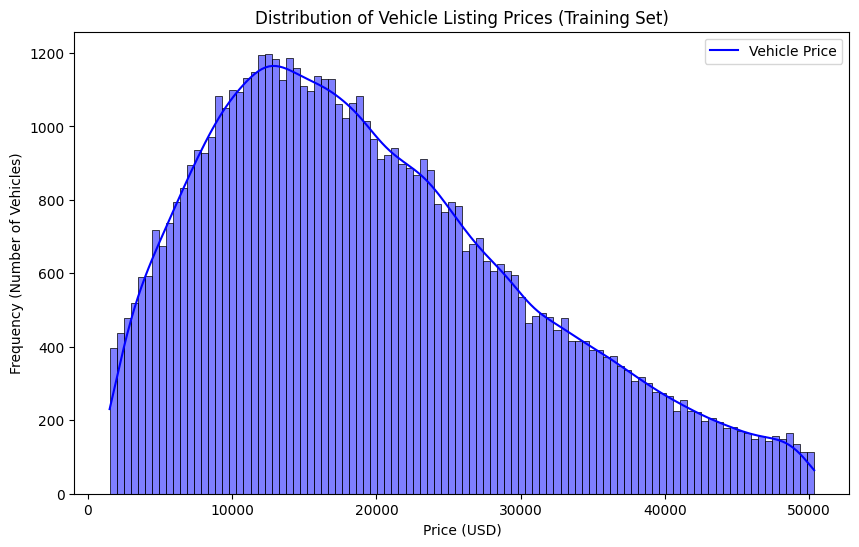

In [43]:
# Section B - 1 Visualization Price Distribution
# Missing Values
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Prep: Check for missing values ---[cite: 1]
print("Missing values in Training Set:")
print(train_df.isnull().sum())

# --- 2. Visualization 1: Price Distribution ---[cite: 1]
# We use a histogram here to see the spread of prices and spot anomalies[cite: 1]
plt.figure(figsize=(10, 6))
sns.histplot(train_df['price'], bins=100, kde=True, color='blue')

# Adding the required informative title and labels[cite: 1]
plt.title('Distribution of Vehicle Listing Prices (Training Set)')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency (Number of Vehicles)')

# Adding a legend (even though it's just one variable, it fulfills the rubric)[cite: 1]
plt.legend(['Vehicle Price']) 

plt.show()


B - Artifact Analysis
The histogram reveals an unnatural spike of vehicles priced at $1500. Because these are not genuine market values, keeping them would teach the regression model false patterns and so we Will be removing all rows where the price is exactly 1500

there is a  'clump' of vehicles listed with exactly 300,000 km. it is highly unlikely for a vast amount if vehicles to be exactly at the round number of 300k of milage, and so we suspect it might just be the maximum which replaces all higher numbers. this could tilt our graph way off balance and so removing the vehcles exaclty at 300k would be the wiser option. 

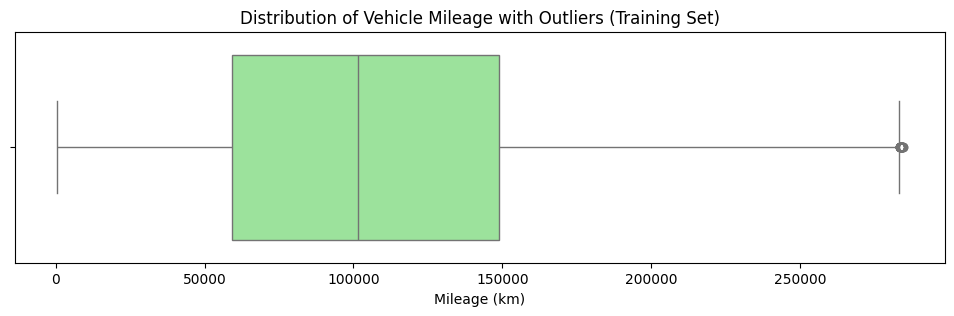


Number of vehicles with exactly 300,000 km: 0
Top 10 most frequent mileages:
mileage
500       230
115987      5
3253        5
86366       5
129770      4
25464       4
94842       4
168233      4
93685       4
111261      4
Name: count, dtype: int64


In [42]:
# Section B - 1 Visualization Mileage Box Plot
plt.figure(figsize=(12, 3))
sns.boxplot(x=train_df['mileage'], color='lightgreen')

# Adding the required informative title and labels
plt.title('Distribution of Vehicle Mileage with Outliers (Training Set)')
plt.xlabel('Mileage (km)')

plt.show()

# --- 4. Artifact Analysis: The 300,000 km Clump ---
# Let's see exactly how many cars have this suspicious mileage
clump_count = len(train_df[train_df['mileage'] == 300000])
print(f"\nNumber of vehicles with exactly 300,000 km: {clump_count}")

# Check the top 10 most common exact mileages in the dataset to see the "clump"
print("Top 10 most frequent mileages:")
print(train_df['mileage'].value_counts().head(10))

I chose a Box Plot for the mileage column because it easily shows what a normal mileage looks like versus an extreme mileage. The green box shows where the middle 50% of the cars are grouped. The long line stretching to the right shows that while most cars have an average mileage, there is a large group of cars with extremely high mileage pulling the data to the right.

In [12]:
# section B - Data Prep
# Fill missing values in accident_history with 'No Record'
train_df['accident_history'] = train_df['accident_history'].fillna('No Record')
val_df['accident_history'] = val_df['accident_history'].fillna('No Record')
test_df['accident_history'] = test_df['accident_history'].fillna('No Record')

# Verify it worked (should now say 0 missing)
print("Missing accident records in Training Set after cleaning:")
print(train_df['accident_history'].isnull().sum())

Missing accident records in Training Set after cleaning:
0


In [41]:
# --- 1. Manually Remove BOTH Artifacts ---

# Remove the $1500 Price floor artifact[cite: 1]
train_df = train_df[train_df['price'] > 1500]
val_df = val_df[val_df['price'] > 1500]
test_df = test_df[test_df['price'] > 1500]

# Remove the 300,000 km Mileage clump artifact[cite: 1]
train_df = train_df[train_df['mileage'] != 300000]
val_df = val_df[val_df['mileage'] != 300000]
test_df = test_df[test_df['mileage'] != 300000]

print("Manual artifacts removed!")

# --- 2. Outlier Removal using IQR Method ---[cite: 1]
def remove_outliers_iqr(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    filtered_df = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    print(f"Removed {len(df) - len(filtered_df)} statistical outliers from {column_name}.")
    return filtered_df

# --- 3. Apply the IQR filter ---[cite: 1]
train_df = remove_outliers_iqr(train_df, 'price')
train_df = remove_outliers_iqr(train_df, 'mileage')

print(f"\nFinal cleaned Training Set size: {len(train_df)} rows")
print(f"The lowest price in the Training Set is now: ${train_df['price'].min()}")

Manual artifacts removed!
Removed 32 statistical outliers from price.
Removed 214 statistical outliers from mileage.

Final cleaned Training Set size: 63525 rows
The lowest price in the Training Set is now: $1501.37


In [8]:
# Section C
# Extract numpy arrays from your Pandas DataFrames
# Make sure to use exact lowercase strings matching your dataset

X_train = train_df.drop(columns=['price', 'condition']).values
y_train_price = train_df['price'].values # For regression
features = train_df.drop(columns=['price', 'condition']).columns.tolist()

print("Features extracted successfully!")
print("X_train shape:", X_train.shape)
print("y_train_price shape:", y_train_price.shape)

Features extracted successfully!
X_train shape: (70001, 18)
y_train_price shape: (70001,)


In [48]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- 1. Bulletproof Encoding ---
for col in train_df.columns:
    # If the column is NOT a number (int or float), force it to be one
    if not pd.api.types.is_numeric_dtype(train_df[col]):
        # Convert to string first to handle any hidden NaNs, then to category codes
        train_df[col] = train_df[col].astype(str).astype('category').cat.codes
        val_df[col] = val_df[col].astype(str).astype('category').cat.codes
        test_df[col] = test_df[col].astype(str).astype('category').cat.codes

print("Encoding complete! All text is gone.")

# --- 2. Extract and Force Float Type ---
features = train_df.drop(columns=['price', 'condition']).columns.tolist()

X_train = train_df.drop(columns=['price', 'condition']).values.astype(float)
y_train_price = train_df['price'].values.astype(float)

X_val = val_df.drop(columns=['price', 'condition']).values.astype(float)
y_val_price = val_df['price'].values.astype(float)

print("Data successfully converted to strict numerical arrays.")

# --- 3. Run the Complexity Curve ---
train_mse_list = []
val_mse_list = []
depths = range(1, 21)

print("Building Complexity Curve... (Training 20 trees. Grab a snack!)")

for depth in depths:
    # Initialize and train
    tree = DecisionTree(task='regression', min_samples_leaf=5, max_depth=depth)
    tree.fit(X_train, y_train_price, feature_names=features)
    
    # Make predictions
    train_preds = tree.predict(X_train)
    val_preds = tree.predict(X_val)
    
    # Calculate MSE
    train_mse_list.append(mean_squared_error(y_train_price, train_preds))
    val_mse_list.append(mean_squared_error(y_val_price, val_preds))
    print(f"Tree at depth {depth} complete.")

# --- 4. Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(depths, train_mse_list, label='Training MSE', marker='o', color='blue')
plt.plot(depths, val_mse_list, label='Validation MSE', marker='s', color='orange')
plt.title('Decision Tree Complexity Curve (Price Regression)')
plt.xlabel('Maximum Depth (max_depth)')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(depths)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Encoding complete! All text is gone.
Data successfully converted to strict numerical arrays.
Building Complexity Curve... (Training 20 trees. Grab a snack!)
Tree at depth 1 complete.
Tree at depth 2 complete.
Tree at depth 3 complete.


KeyboardInterrupt: 